This notebook presents the code for a basic experiment to detect inductive bias in models. It replicates the results obtained by [Dorell et al.](https://arxiv.org/pdf/2211.13544) 

The algorithm proceeds as follows: the meta-learner generates labels for a dataset, which is subsequently used to train the learner; the learner's generalization performance on these labels is then evaluated and incorporated into the meta-loss function. In this way, the meta-learner is trained to find functions that the learner can easily generalize.

This algorithm performed well on the examples considered in the original paper, but it has several limitations. First, it requires knowledge of the data distribution or a fixed dataset. Second, its analysis of inductive bias is constrained by the characteristics of this fixed data.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from geomloss import SamplesLoss

In [2]:
# Parameters
BATCH_SIZE = 30
NUM_ITERATIONS = 200
NUM_PLOT_POINTS = 10000
LEARNING_RATE = 0.01

HIDDEN_SIZE = 20
NUM_LAYERS = 4

RIDGE_ALPHA = 0.001

LOSS_DISTR_WEIGHT = 1e6
LOSS_ORTHO_WEIGHT = 10.0
LOSS_LINEAR_WEIGHT = 1.0

The dataset consists of points uniformly distributed within a unit circle.

In [3]:
def generate_uniform_in_circle(n_points):
    """
    Generates n_points points uniformly distributed within a unit circle.
    Returns a tensor of size [n_points, 2] with the coordinates of the points.
    """
    points = torch.zeros([n_points, 2])
    
    for i in range(n_points):
        # Random angle from 0 to 2π
        theta = np.random.uniform(0, 2 * np.pi)
        
        # Random distance from 0 to 1
        r_2 = np.random.uniform(0, 1)
        r = np.sqrt(r_2) # for uniformity over the area of ​​the circle
        
        # Transition from polar to Cartesian coordinates
        points[i, 0] = r * np.cos(theta)
        points[i, 1] = r * np.sin(theta)
    
    return points

The target model is a linear regression, and the meta-learner, that is trained to generate labels for it, is a MLP.

In [4]:
# Learner
def linear_learner(X_train, y_train, X_test):
    """
    Linear regression model.
    Predicts y given X, trained on (X_train, y_train).
    """
    X = X_train
    y = y_train
    
    XtX = torch.matmul(X.T, X)
    XtX_reg = XtX + RIDGE_ALPHA * torch.eye(2)
    XtX_inv = torch.inverse(XtX_reg)
    w = torch.matmul(torch.matmul(XtX_inv, X.T), y)
    
    return torch.matmul(X_test, w)

def linear_mse_loss(x_tr, z_tr, x_te, z_te):
    z_linear = linear_learner(x_tr, z_tr, x_te)
    return torch.mean((z_te - z_linear) ** 2)


# Meta-learner
class MetaLearner(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(2, HIDDEN_SIZE)
        self.linearh = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE)
        self.linear2 = nn.Linear(HIDDEN_SIZE, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.linear1(x)
        for _ in range(NUM_LAYERS - 1):
            out = self.relu(out)
            out = self.linearh(out)
        out = self.relu(out)
        out = self.linear2(out)
        return out

The meta-loss measures the model's prediction error, the distance of our label distribution from uniform, and has an orthogonal term.

In [5]:
# Meta-loss
sinkhorn = SamplesLoss(loss="sinkhorn", p=2, blur=0.05)

def get_target_distribution(n_samples):
    return 2 * torch.rand(n_samples, 1) - 1

def distribution_loss(z_tr, z_te):
    """Penalty to avoid trivial decisions."""
    target = get_target_distribution(BATCH_SIZE // 2)
    return sinkhorn(z_tr, target) + sinkhorn(z_te, target)


def orthogonality_loss(z_fixed, prev_fixed_values):
    """
    Penalty for orthogonalization with previous functions.

    Args:
    z_fixed: values ​​of the current function at fixed points.
    prev_fixed_values: list of values ​​of previous functions at the same points.
    """
    ortho_loss = 0.0
    if prev_fixed_values is not None:
        for prev_z in prev_fixed_values:
            dot = torch.sum(z_fixed[:, 0] * prev_z[:, 0])
            ortho_loss = ortho_loss + dot ** 2
    return ortho_loss

def meta_loss(x_tr, x_te, z_tr, z_te, z_fixed, prev_fixed_values=None):
    """
    Complete loss function for the meta-learner.
    """
    d_loss = distribution_loss(z_tr, z_te)
    l_loss = linear_mse_loss(x_tr, z_tr, x_te, z_te)
    o_loss = orthogonality_loss(z_fixed, prev_fixed_values)
    
    return (LOSS_DISTR_WEIGHT * d_loss + 
            LOSS_LINEAR_WEIGHT * l_loss + 
            LOSS_ORTHO_WEIGHT * o_loss)

The meta-learning loop consists of generating training and test samples, calculating their labels using a meta-learner, training and testing the target model on the resulting dataset and and computing the meta-loss function for a meta-learning step.

In [6]:
# Meta-training
def train_meta_learner(fixed_points, prev_fixed_values=None):
    """
    Function for training the meta-learner.

    Args:
    fixed_points: Fixed points for orthogonality and visualization.
    prev_fixed_values: List of previous function values ​​at fixed_points.
    function_index: Function index (for log).

    Returns:
    model: Trained model.
    z_fixed: Function values ​​at fixed_points.
    """
    model = MetaLearner()
    optimizer = optim.Adagrad(model.parameters(), lr=LEARNING_RATE)
    
    for step in range(NUM_ITERATIONS):
        optimizer.zero_grad()
        
        x_tr = generate_uniform_in_circle(BATCH_SIZE // 5)
        x_te = generate_uniform_in_circle(BATCH_SIZE // 5 * 4)
        
        
        z_tr = model(x_tr)
        z_te = model(x_te)
        z_fixed = model(fixed_points)
        
        loss = meta_loss(x_tr, x_te, z_tr, z_te, z_fixed, prev_fixed_values)
        
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        z_fixed = model(fixed_points)
    
    return model, z_fixed

# Visualization
def plot_functions(fixed_points, z_list, titles):
    plt.figure(figsize=(12, 4))
    
    for i, (z, title) in enumerate(zip(z_list, titles)):
        plt.subplot(1, 3, i + 1)
        plt.scatter(fixed_points[:, 0], fixed_points[:, 1], 
                   c=z.numpy(), cmap='viridis', s=10)
        plt.colorbar()
        plt.title(title)
        plt.axis('equal')
    
    plt.tight_layout()
    plt.show()

Let's conduct an experiment and find three orthogonal functions that can be easily generalized by linear regression.

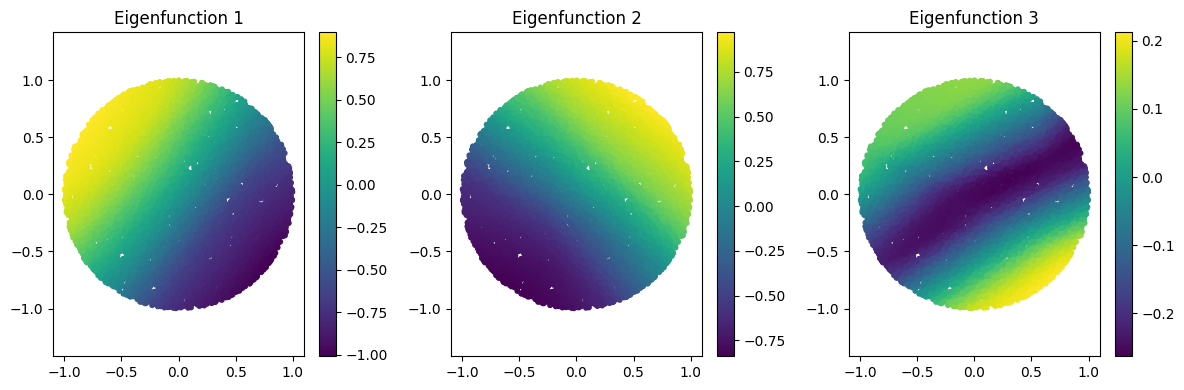

In [12]:
# Experiment
fixed_points = generate_uniform_in_circle(NUM_PLOT_POINTS)

models = []
z_values = []
prev_fixed = None
    
for i in range(1, 4):
    model, z_fixed = train_meta_learner(
        fixed_points=fixed_points,
        prev_fixed_values=prev_fixed
    )
    models.append(model)
    z_values.append(z_fixed)
    prev_fixed = z_values.copy()

plot_functions(fixed_points, z_values, 
                  ["Eigenfunction 1", "Eigenfunction 2", "Eigenfunction 3"])

As can be seen, three orthogonal linear functions are observed during the experiment, which corresponds to the well-known inductive bias of the linear regression model.